In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
import math
from sklearn.linear_model import LogisticRegression
from pandas import date_range
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from statsmodels.graphics.tsaplots import plot_pacf
def score_dataset(X, y, model = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings
def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

In [2]:
rain_file_path = 'data/train2_1.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [3]:
test_data.fillna(value=160, inplace=True)

In [4]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1
...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [5]:
rain_data["year"] = (rain_data.index + 1) / 365
rain_data["year"] = np.ceil(rain_data.year)
rain_data = rain_data.astype({'year': 'int64'})

In [6]:
rain_data.dtypes

pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
rainfall           int64
year               int64
dtype: object

In [7]:
rain_data.year = rain_data.year.replace(8, 7)

<Axes: xlabel='year', ylabel='mintemp'>

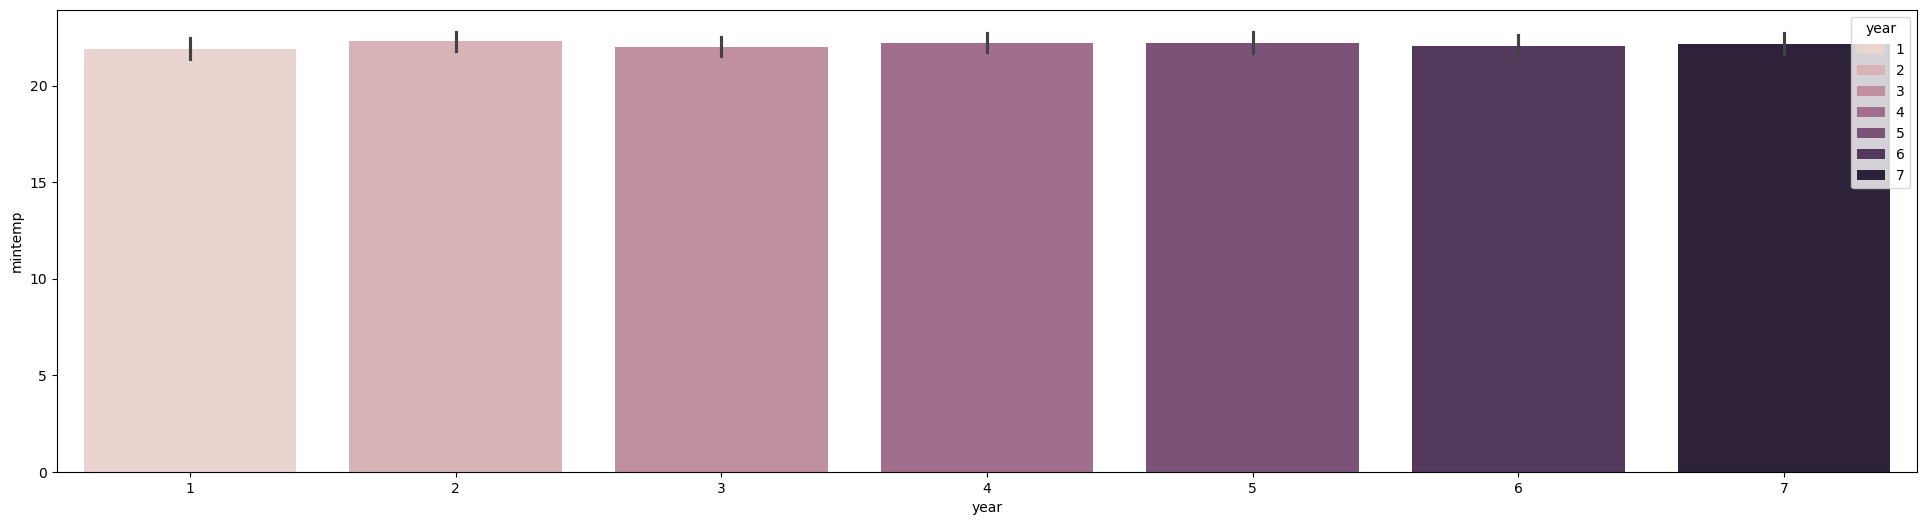

In [8]:
plt.figure(figsize=(24,6))
sns.barplot(y=rain_data.mintemp, x=rain_data.year, hue=rain_data.year)

In [9]:
for a in range(1,8):
    b = rain_data.loc[(rain_data.year == a ) & (rain_data.rainfall == 1)]
    print(b.shape)

(249, 12)
(265, 12)
(275, 12)
(272, 12)
(274, 12)
(276, 12)
(288, 12)


In [10]:
test_data["year"] = (test_data.index + 1) / 365
test_data["year"] = np.ceil(test_data.year)
test_data["year"] = test_data["year"] + 7
test_data = test_data.astype({'year': 'int64'})

In [11]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,1
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7


In [12]:
test_data = test_data.drop(labels=["id", "day"], axis=1)
rain_data.index = date_range("2013-1-1", freq="D", periods=2556)
test_data.index = date_range("2020-1-1", freq="D", periods=730)

<Axes: ylabel='rainfall'>

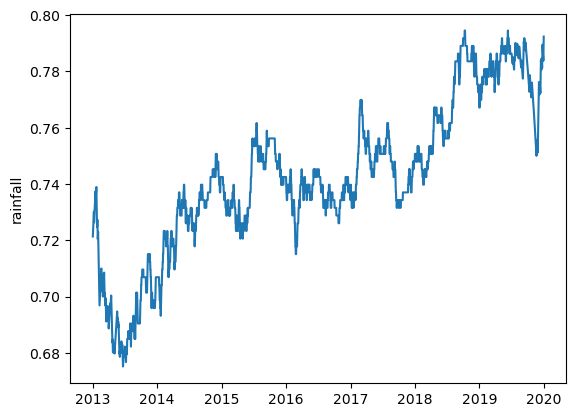

In [13]:
trend = rain_data.rainfall.rolling(
    window=365,
    center=True,
    min_periods=182
).mean()
sns.lineplot(data=trend)

/var/folders/g_/xlgpd__x3y70c42xrmy8vz5h0000gn/T/ipykernel_2299/1277143335.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=X, x=X.index, y="trend", palette = "bright")


<Axes: xlabel='None', ylabel='trend'>

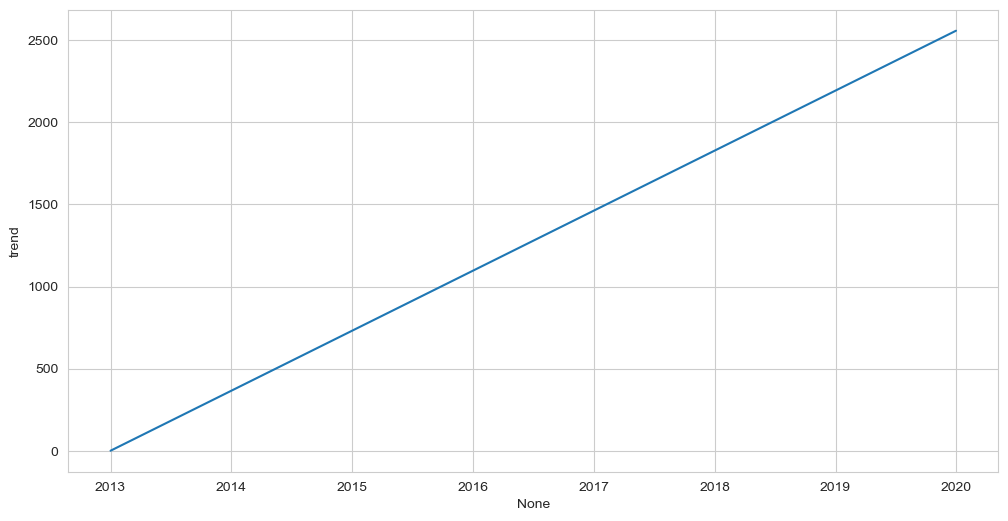

In [14]:
dp = DeterministicProcess(
    index=rain_data.index,
    order=2,
    drop=True
)

# YOUR CODE HERE: Create the feature set for the dates given in y.index
X = dp.in_sample()

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(data=X, x=X.index, y="trend", palette = "bright") 

In [15]:
y = rain_data.rainfall

In [16]:
dp = DeterministicProcess(index=y.index, order=1)
X = dp.in_sample()

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

In [17]:
rain_data["trend"] = y_pred

<Axes: xlabel='None', ylabel='trend'>

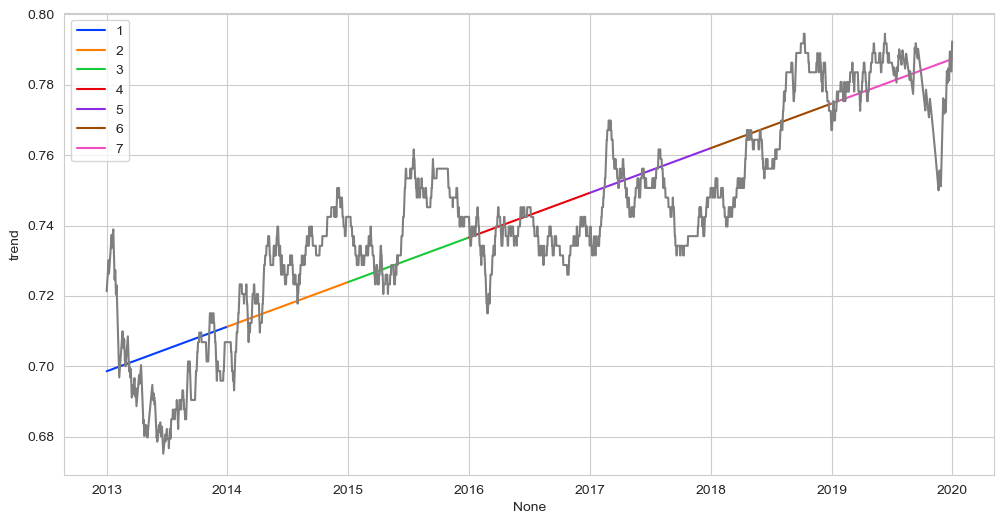

In [18]:
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(data=rain_data, x=rain_data.index, y="trend", hue="year", palette = "bright") 
sns.lineplot(data=trend)

In [19]:
X = dp.out_of_sample(steps=730)
y_fore = pd.Series(model.predict(X), index=X.index)

In [20]:
test_data["trend"] = y_fore

In [21]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.232838
sunshine         0.161076
humidity         0.130928
trend            0.084347
dewpoint         0.033111
temparature      0.028568
maxtemp          0.026417
mintemp          0.012622
pressure         0.011168
year             0.008852
windspeed        0.004863
winddirection    0.000524
Name: MI Scores, dtype: float64

In [22]:
fourier = CalendarFourier(freq="A", order=1)
dp = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    # YOUR CODE HERE
    seasonal=False,
    additional_terms=[fourier],
    drop=True,
)
X = dp.in_sample()


/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [23]:
model = LinearRegression().fit(X, y)
y_pred = pd.Series(
    model.predict(X),
    index=X.index,
    name='Fitted',
)

In [24]:
X = dp.out_of_sample(steps=730)
y_furier_fore = pd.Series(model.predict(X), index=X.index)
test_data["furier"] = y_furier_fore

<Axes: xlabel='None', ylabel='Fitted'>

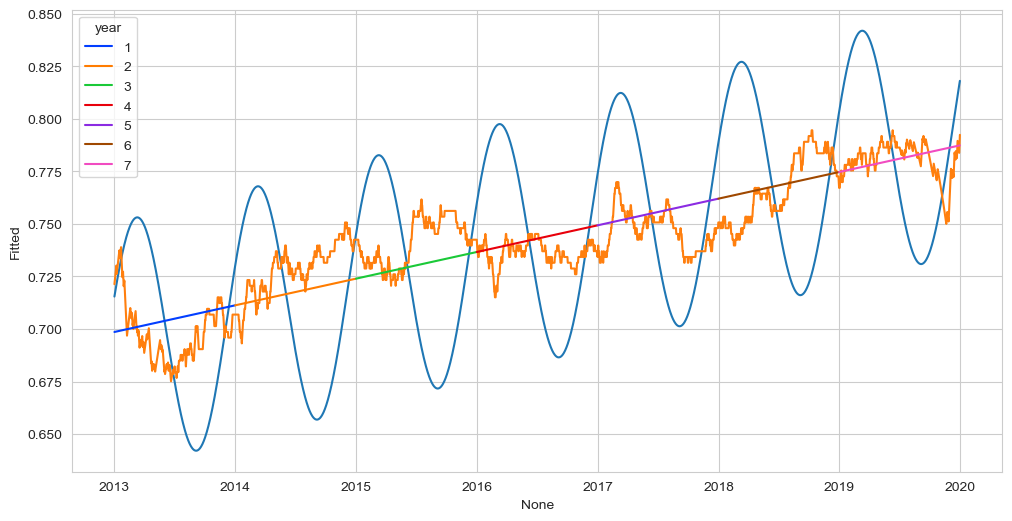

In [25]:
plt.figure(figsize=(12,6))
sns.lineplot(data=y_pred)#, x=rain_data.index, y="y_pred", hue="year", palette = "bright") 
sns.lineplot(data=trend)
sns.lineplot(data=rain_data, x=rain_data.index, y="trend", hue="year", palette = "bright") 

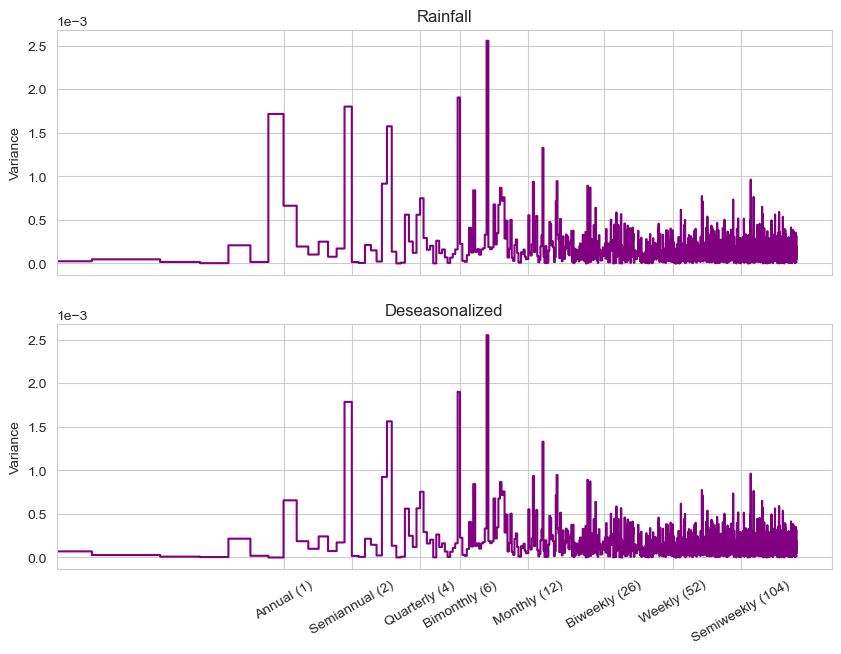

In [26]:
y_deseason = y - y_pred

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(10, 7))
ax1 = plot_periodogram(y, ax=ax1)
ax1.set_title("Rainfall")
ax2 = plot_periodogram(y_deseason, ax=ax2);
ax2.set_title("Deseasonalized");

In [27]:
rain_data["furier"] = y_pred

In [28]:
print("rain_data")
print(rain_data.columns)
print("test_data")
print(test_data.columns)

rain_data
Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed', 'rainfall', 'year',
       'trend', 'furier'],
      dtype='object')
test_data
Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed', 'year', 'trend',
       'furier'],
      dtype='object')


In [29]:
X_test = test_data
X_test.index = date_range("2020-1-1", freq="D", periods=730)

In [30]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
print(mi_scores)
score_dataset(X, y)

cloud            0.201174
sunshine         0.175882
humidity         0.114823
trend            0.083678
temparature      0.028422
dewpoint         0.024082
windspeed        0.022615
mintemp          0.018473
furier           0.011306
pressure         0.010022
maxtemp          0.005718
winddirection    0.004973
year             0.000614
Name: MI Scores, dtype: float64
0.8912259550882924


In [31]:
rain_data = rain_data.drop(labels = "year", axis=1)
test_data = test_data.drop(labels = "year", axis=1)

In [32]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
print(mi_scores)
score_dataset(X, y)

cloud            0.193392
sunshine         0.157840
humidity         0.152153
trend            0.083838
temparature      0.039216
maxtemp          0.024880
dewpoint         0.024858
mintemp          0.015955
pressure         0.013266
furier           0.011306
winddirection    0.000000
windspeed        0.000000
Name: MI Scores, dtype: float64
0.8904098671397292


In [33]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
print(mi_scores)
score_dataset(X, y)

cloud            0.220051
sunshine         0.151564
humidity         0.138367
trend            0.082860
mintemp          0.036562
temparature      0.031987
dewpoint         0.015740
windspeed        0.015141
pressure         0.014266
furier           0.011306
winddirection    0.006878
maxtemp          0.004744
Name: MI Scores, dtype: float64
0.8904098671397292


In [34]:
cols = ["cloud", "sunshine", "humidity", "trend"]
cols_for_scaling = X.loc[:, cols]
test_cols_for_scaling = X_test.loc[:, cols]

In [35]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(test_cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

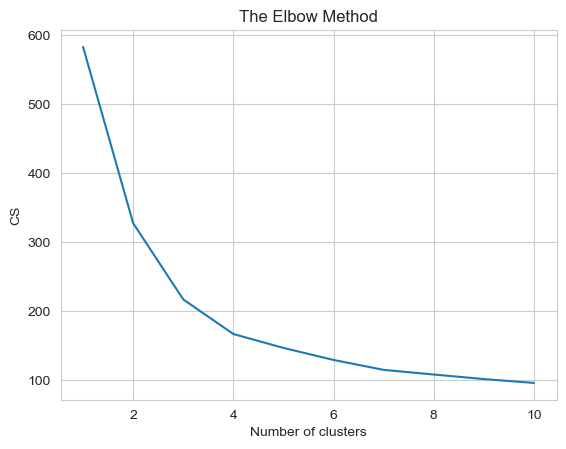

In [36]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [37]:
kmeans = KMeans(n_clusters=4, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 992 out of 2556 samples were correctly labeled.
Accuracy score: 0.39


In [38]:
X_scaled["cluster"] = kmeans.predict(X_scaled)
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [39]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])
X_test_cd.index = date_range("2020-1-1", freq="D", periods=730)

In [40]:
X_test_scaled.shape

(730, 5)

In [41]:
X_cd.index = date_range("2013-1-1", freq="D", periods=2556)
X_scaled.index = date_range("2013-1-1", freq="D", periods=2556)
X_test_scaled.index = data_range (

In [42]:
X_test_cd


,Centroid_0,Centroid_1,Centroid_2,Centroid_3
2020-01-01,2.142701,0.355398,3.130582,1.554515
2020-01-02,2.143624,0.363869,3.132193,1.557543
2020-01-03,2.133667,0.286183,3.114471,1.517529
2020-01-04,1.406496,3.079231,0.303025,2.147596
2020-01-05,1.486610,3.115663,0.324390,2.147956
...,...,...,...,...
2021-12-26,0.341434,2.151161,1.502990,1.355707
2021-12-27,0.305980,2.141685,1.382054,1.206045
2021-12-28,0.318955,2.147643,1.494312,1.344215
2021-12-29,0.324885,2.149082,1.493757,1.342670


In [43]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)
X["cluster"] = X_scaled["cluster"]
X_test["cluster"] = X_test_scaled["cluster"]

In [45]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
print(mi_scores)
score_dataset(X, y)

cloud            0.221093
Centroid_0       0.189083
Centroid_2       0.182689
sunshine         0.161201
Centroid_1       0.159228
Centroid_3       0.154443
humidity         0.146409
cluster          0.125684
trend            0.081698
dewpoint         0.030940
maxtemp          0.027514
temparature      0.023217
furier           0.011306
pressure         0.007928
windspeed        0.006113
mintemp          0.001809
winddirection    0.000000
Name: MI Scores, dtype: float64
0.8903047762116211


In [46]:
print("X")
print(X.columns)
print("test_data")
print(X_test.columns)

X
Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed', 'trend', 'furier',
       'Centroid_0', 'Centroid_1', 'Centroid_2', 'Centroid_3', 'cluster'],
      dtype='object')
test_data
Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed', 'year', 'trend',
       'furier', 'Centroid_0', 'Centroid_1', 'Centroid_2', 'Centroid_3',
       'cluster'],
      dtype='object')


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8891652305885884


In [48]:
%%time
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "penalty": ["l1", "l2"]
}

model_logistic_regression = LogisticRegression(
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

model_logistic_regression = GridSearchCV(
    model_logistic_regression, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_logistic_regression.fit(X, y)

print('-----')
print(f'Best parameters {model_logistic_regression.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + 
    f'{model_logistic_regression.best_score_:.3f}'
)
cross_valid_scores['logistic_regression'] = model_logistic_regression.best_score_
print('-----')

/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/sit

-----
Best parameters {'C': 0.1, 'penalty': 'l1'}
Mean cross-validated accuracy score of the best_estimator: 0.891
-----
CPU times: user 8.26 s, sys: 124 ms, total: 8.38 s
Wall time: 10.1 s


In [49]:
%%time
from sklearn.ensemble import RandomForestClassifier

# Parametr tuning GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}

parameters = {
    "n_estimators": [5, 10, 15, 20, 25], 
    "max_depth": [3, 5, 7, 9, 11, 13],
}

model_random_forest = RandomForestClassifier(
    random_state=0,
    class_weight='balanced',
)

model_random_forest = GridSearchCV(
    model_random_forest, 
    parameters, 
    cv=5,
    scoring='roc_auc',
)

model_random_forest.fit(X, y)

print('-----')
print(f'Best parameters {model_random_forest.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' + \
    f'{model_random_forest.best_score_:.3f}'
)
cross_valid_scores['desicion_tree'] = model_random_forest.best_score_
print('-----')

-----
Best parameters {'max_depth': 3, 'n_estimators': 25}
Mean cross-validated accuracy score of the best_estimator: 0.875
-----
CPU times: user 9.97 s, sys: 110 ms, total: 10.1 s
Wall time: 10.9 s


In [50]:
model_logistic_regression = LogisticRegression(C=0.1, penalty="l1",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

In [51]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,trend,furier,Centroid_0,Centroid_1,Centroid_2,Centroid_3,cluster
2013-01-01,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,0.698583,0.715434,1.480614,2.133437,1.292681,0.252530,2
2013-01-02,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,0.698618,0.716400,2.141549,1.401487,0.272663,1.256438,1
2013-01-03,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,0.698653,0.717358,2.149251,1.467686,0.325747,1.338541,1
2013-01-04,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,0.698687,0.718308,2.141326,1.411119,0.268698,1.271184,1
2013-01-05,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,0.698722,0.719251,2.148866,1.448723,0.324197,1.313540,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,0.787193,0.814065,0.325254,3.113866,2.145081,1.519788,3
2019-12-28,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,0.787228,0.815064,0.280999,3.106978,2.139186,1.504617,3
2019-12-29,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,0.787263,0.816056,0.403676,3.029828,2.157950,1.319105,3
2019-12-30,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,0.787298,0.817043,0.292968,3.111611,2.140925,1.516367,3


In [52]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,trend,furier,Centroid_0,Centroid_1,Centroid_2,Centroid_3,cluster
2020-01-01,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,8,0.787367,0.818995,2.142701,0.355398,3.130582,1.554515,NaN
2020-01-02,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,8,0.787402,0.819959,2.143624,0.363869,3.132193,1.557543,NaN
2020-01-03,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,8,0.787437,0.820914,2.133667,0.286183,3.114471,1.517529,NaN
2020-01-04,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,8,0.787471,0.821862,1.406496,3.079231,0.303025,2.147596,NaN
2020-01-05,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,8,0.787506,0.822802,1.486610,3.115663,0.324390,2.147956,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-26,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,9,0.812550,0.842678,0.341434,2.151161,1.502990,1.355707,NaN
2021-12-27,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,9,0.812585,0.843683,0.305980,2.141685,1.382054,1.206045,NaN
2021-12-28,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,9,0.812620,0.844682,0.318955,2.147643,1.494312,1.344215,NaN
2021-12-29,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,9,0.812655,0.845674,0.324885,2.149082,1.493757,1.342670,NaN


In [61]:
X_test.isnull().sum()

pressure           0
maxtemp            0
temparature        0
mintemp            0
dewpoint           0
humidity           0
cloud              0
sunshine           0
winddirection      0
windspeed          0
year               0
trend              0
furier             0
Centroid_0         0
Centroid_1         0
Centroid_2         0
Centroid_3         0
cluster          730
dtype: int64

In [60]:
model_logistic_regression.fit(X, y)
rf_test_preds = model_logistic_regression.predict(X_test)

/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- year

  warnings.warn(message, FutureWarning)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values